In [ ]:
# ============================================================
# HASHING AND SETS:
# Python + Matplotlib + Pandas
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ------------------------------------------------------------
# PART 1: CREATE A SIMPLE HASH FUNCTION
# ------------------------------------------------------------
print("PART 1: HASH FUNCTION")
def hash_function(name, size):
    # Add character values and find the bucket
    return sum(ord(char) for char in name) % size

PART 1: HASH FUNCTION


In [ ]:
print(hash_function("Amit", 5))

0


In [ ]:
print(hash_function("Ravi", 5))

2


In [ ]:
print(hash_function("Neha", 5))

0


In [ ]:
# ------------------------------------------------------------
# PART 2: CREATE A HASH TABLE
# ------------------------------------------------------------
print("\nPART 2: CREATE HASH TABLE")
size = 5
table = [[] for _ in range(size)]

print(table)

# Each inner list represents one bucket.
# ------------------------------------------------------------
# PART 3: INSERT ITEMS USING A FUNCTION
# ------------------------------------------------------------
print("\nPART 3: INSERT ITEMS")

def insert(table, name):
    bucket = hash_function(name, len(table))
    table[bucket].append(name)
    print(name, "stored in bucket", bucket)

insert(table, "Amit")
insert(table, "Ravi")
insert(table, "Neha")
insert(table, "Priya")
insert(table, "Rahul")
insert(table, "Anu")


PART 2: CREATE HASH TABLE
[[], [], [], [], []]

PART 3: INSERT ITEMS
Amit stored in bucket 0
Ravi stored in bucket 2
Neha stored in bucket 0
Priya stored in bucket 2
Rahul stored in bucket 3
Anu stored in bucket 2


In [ ]:
print("\nCurrent table:")
for i, bucket in enumerate(table):
    print(i, bucket)


Current table:
0 ['Amit', 'Neha']
1 []
2 ['Ravi', 'Priya', 'Anu']
3 ['Rahul']
4 []


In [ ]:
# ------------------------------------------------------------
# PART 4: SEARCH FOR AN ITEM
# ------------------------------------------------------------
print("\nPART 4: SEARCH")
def search(table, name):
    bucket = hash_function(name, len(table))

    if name in table[bucket]:
        print(name, "was found in bucket", bucket)
        return True
    else:
        print(name, "was not found")
        return False

search(table, "Amit")
search(table, "John")


PART 4: SEARCH
Amit was found in bucket 0
John was not found


False

In [ ]:
# ------------------------------------------------------------
# PART 5: DELETE AN ITEM
# ------------------------------------------------------------
print("\nPART 5: DELETE")
def delete(table, name):
    bucket = hash_function(name, len(table))

    if name in table[bucket]:
        table[bucket].remove(name)
        print(name, "deleted")
        return True
    else:
        print(name, "not found")
        return False


PART 5: DELETE


In [ ]:
delete(table, "Ravi")

Ravi deleted


True

In [ ]:
delete(table, "John")

John not found


False

In [ ]:
print("Table after deletion:")
for i, bucket in enumerate(table):
    print(i, bucket)

Table after deletion:
0 ['Amit', 'Neha']
1 []
2 ['Priya', 'Anu']
3 ['Rahul']
4 []


In [ ]:
# ------------------------------------------------------------
# PART 6: COUNT COLLISIONS
# ------------------------------------------------------------
print("\nPART 6: COLLISION COUNT")

names = [
    "Amit", "Ravi", "Neha", "Priya", "Rahul",
    "Anu", "Kiran", "Meera", "Arun", "John",
    "Sneha", "Rohan", "Kavya", "Manu", "Deepa"
]

size = 5
table = [[] for _ in range(size)]
collisions = 0
collision_data = []

for name in names:
    bucket = hash_function(name, size)

    # Collision if this bucket is already occupied
    if len(table[bucket]) > 0:
        collisions += 1

    table[bucket].append(name)

    collision_data.append({
        "Name": name,
        "Bucket": bucket,
        "Total Collisions": collisions
    })

collision_df = pd.DataFrame(collision_data)

print(collision_df)
print("Total collisions:", collisions)



PART 6: COLLISION COUNT
     Name  Bucket  Total Collisions
0    Amit       0                 0
1    Ravi       2                 0
2    Neha       0                 1
3   Priya       2                 2
4   Rahul       3                 2
5     Anu       2                 3
6   Kiran       1                 3
7   Meera       0                 4
8    Arun       1                 5
9    John       4                 5
10  Sneha       0                 6
11  Rohan       4                 7
12  Kavya       3                 8
13   Manu       1                 9
14  Deepa       4                10
Total collisions: 10



PART 7: COLLISION GRAPH


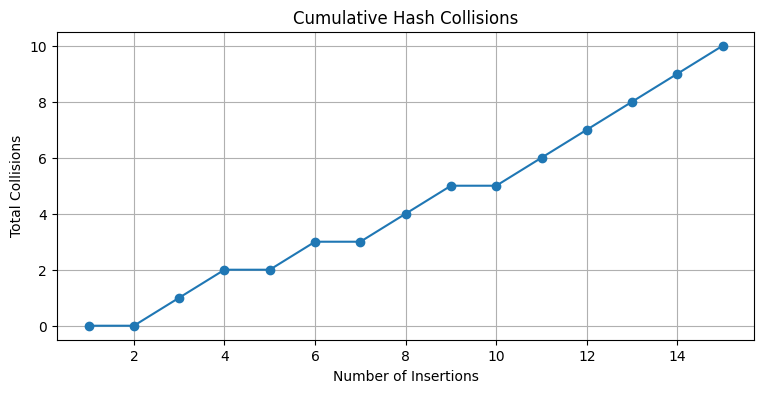

In [ ]:
# ------------------------------------------------------------
# PART 7: VISUALISE COLLISIONS
# ------------------------------------------------------------

print("\nPART 7: COLLISION GRAPH")

plt.figure(figsize=(9, 4))

plt.plot(
    range(1, len(names) + 1),
    collision_df["Total Collisions"],
    marker="o"
)

plt.title("Cumulative Hash Collisions")
plt.xlabel("Number of Insertions")
plt.ylabel("Total Collisions")
plt.grid(True)
plt.show()




PART 8: BUCKET OCCUPANCY


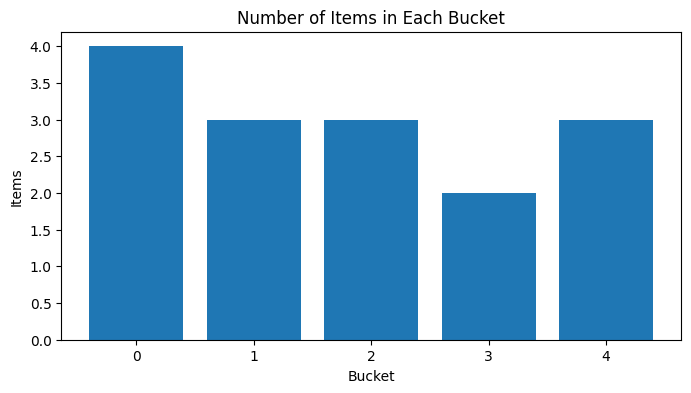

In [ ]:
# ------------------------------------------------------------
# PART 8: VISUALISE BUCKET OCCUPANCY
# ------------------------------------------------------------

print("\nPART 8: BUCKET OCCUPANCY")

bucket_sizes = [len(bucket) for bucket in table]

plt.figure(figsize=(8, 4))
plt.bar(range(size), bucket_sizes)

plt.title("Number of Items in Each Bucket")
plt.xlabel("Bucket")
plt.ylabel("Items")
plt.xticks(range(size))
plt.show()


In [ ]:
# ------------------------------------------------------------
# PART 9: UNDERSTAND LOAD FACTOR
# Load factor = number of items / number of buckets
# ------------------------------------------------------------

print("\nPART 9: LOAD FACTOR")

number_of_items = len(names)
number_of_buckets = size

load_factor = number_of_items / number_of_buckets

print("Number of items:", number_of_items)
print("Number of buckets:", number_of_buckets)
print("Load factor:", round(load_factor, 2))


PART 9: LOAD FACTOR
Number of items: 15
Number of buckets: 5
Load factor: 3.0



PART 10: TABLE SIZE COMPARISON
   Table Size  Items  Collisions  Load Factor
0           5     15          10         3.00
1          10     15           6         1.50
2          15     15           4         1.00
3          20     15           4         0.75


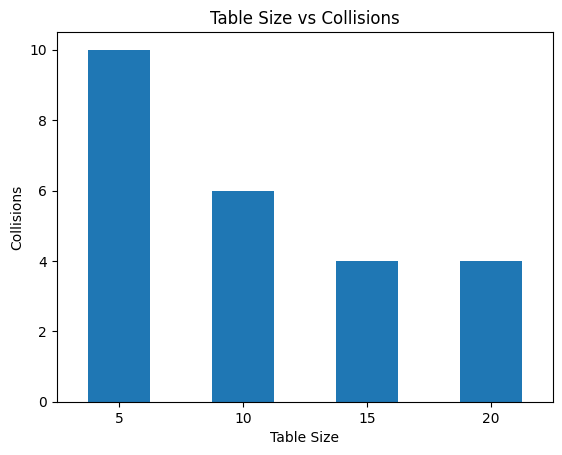

In [ ]:
# ------------------------------------------------------------
# PART 10: COMPARE DIFFERENT TABLE SIZES
# ------------------------------------------------------------

print("\nPART 10: TABLE SIZE COMPARISON")

sizes = [5, 10, 15, 20]
results = []

for current_size in sizes:
    temp_table = [[] for _ in range(current_size)]
    total_collisions = 0

    for name in names:
        bucket = hash_function(name, current_size)

        if len(temp_table[bucket]) > 0:
            total_collisions += 1

        temp_table[bucket].append(name)

    results.append({
        "Table Size": current_size,
        "Items": len(names),
        "Collisions": total_collisions,
        "Load Factor": len(names) / current_size
    })

comparison_df = pd.DataFrame(results)

print(comparison_df)

comparison_df.plot(
    x="Table Size",
    y="Collisions",
    kind="bar",
    legend=False
)

plt.title("Table Size vs Collisions")
plt.ylabel("Collisions")
plt.xticks(rotation=0)
plt.show()


In [ ]:
# ------------------------------------------------------------
# PART 11: PYTHON SETS
# ------------------------------------------------------------
print("\nPART 11: SETS")

class_A = {"Amit", "Ravi", "Neha", "Priya"}
class_B = {"Ravi", "Neha", "Rahul", "Manu"}


PART 11: SETS


In [ ]:
# Students in both classes
print("Intersection:", class_A & class_B)

# Students in either class
print("Union:", class_A | class_B)


Intersection: {'Neha', 'Ravi'}
Union: {'Amit', 'Neha', 'Ravi', 'Rahul', 'Priya', 'Manu'}


In [ ]:
# Students only in Class A
print("Only in A:", class_A - class_B)

Only in A: {'Amit', 'Priya'}


In [ ]:
# Students in exactly one class
print("Symmetric difference:", class_A ^ class_B)

Symmetric difference: {'Amit', 'Rahul', 'Priya', 'Manu'}


In [ ]:
# ------------------------------------------------------------
# PART 12: REMOVE DUPLICATES USING SETS
# ------------------------------------------------------------

print("\nPART 12: REMOVE DUPLICATES")

marks = [80, 90, 80, 75, 90, 60, 75]

unique_marks = set(marks)

print("Original marks:", marks)
print("Unique marks:", unique_marks)
print("Number of original entries:", len(marks))
print("Number of unique marks:", len(unique_marks))


PART 12: REMOVE DUPLICATES
Original marks: [80, 90, 80, 75, 90, 60, 75]
Unique marks: {80, 90, 75, 60}
Number of original entries: 7
Number of unique marks: 4
